# Rossman Store Sales: Forecasting

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import warnings

# Add the parent directory (project root) to sys.path if not already there
parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

warnings.filterwarnings("ignore")

In [3]:
import random
import warnings

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from IPython.core.display_functions import display
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from src.preprocessing import (
    create_store_profile,
    extended_preprocessing_rossmann_xgb,
    prepare_cluster_data_for_training,
    preprocess_rossmann_data,
    preprocess_rossmann_store_data,
    preprocess_store_profile_data,
    split_cluster_data,
    split_train_val_data,
)
from src.processing import cluster_rossmann_stores
from src.utils.evaluation import (
    RossmannEvaluation,
    evaluate_model_performance_on_stores,
    smape,
)

Importing plotly failed. Interactive plots will not work.


## Load datasets

In [4]:
DATA_PATH = "../data/"

train = pd.read_csv(f"{DATA_PATH}/train.csv", parse_dates=["Date"])
test = pd.read_csv(f"{DATA_PATH}/test.csv", parse_dates=["Date"])
store = pd.read_csv(f"{DATA_PATH}/store.csv")

train = train.merge(store, on="Store")
test = test.merge(store, on="Store")

print("Train dataset:")
display(train.head())
display(f"Train size: {train.shape}")

print("Test dataset:")
display(test.head())
display(f"Test size: {test.shape}")

Train dataset:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


'Train size: (1017209, 18)'

Test dataset:


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN


'Test size: (41088, 17)'

## Preprocessing

In [5]:
ptrain = preprocess_rossmann_data(df=train)
ptest = preprocess_rossmann_data(df=test)

pstore = preprocess_rossmann_store_data(data=store)

display(ptrain.head(5))
display(pstore.head(5))

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,days_to_competitor
1016095,1,2,2013-01-01,0,0,0,0,a,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2013,1,1827
1014980,1,3,2013-01-02,5530,668,1,0,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2013,1,1828
1013865,1,4,2013-01-03,4327,578,1,0,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2013,1,1829
1012750,1,5,2013-01-04,4486,619,1,0,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2013,1,1830
1011635,1,6,2013-01-05,4997,635,1,0,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2013,1,1831


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## Modeling

Build forecasting models for Rossmann stores

In [6]:
mlflow.set_tracking_uri("http://localhost:5001/")
mlflow.set_experiment("forecasting_rossmann_hybrid_clustering")

<Experiment: artifact_location='s3://mlflow-artifacts/9', creation_time=1777994873269, experiment_id='9', last_update_time=1777994873269, lifecycle_stage='active', name='forecasting_rossmann_hybrid_clustering', tags={}, trace_location=None, workspace='default'>

### (baseline) Modeling: Prophet

Building one model for each store is not feasible since it's 1110+ store.
Therefore, the initial idea is to **cluster stores and then build models for each cluster**. <br>
First, we build a profile (Avg. Sales and Avg. Customers) for each store. Then, we cluster store profiles.

It's important to mention that one model for all stores is also not possible since we learned from EDA
that we some store are quite different.

#### Create groups

In [ ]:
# Create a store profile
# Tested features: "SchoolHoliday", "Open", "Promo", "Promo2", 'StoreType'
store_features = create_store_profile(data=ptrain, store_data=pstore)

X_processed = preprocess_store_profile_data(profile_data=store_features)

display(store_features.head())

,Store,AvgSales,AvgCustomers,AvgCompetitionDistance,StoreType
0,1,3945.704883,467.646497,1270.0,c
1,2,4122.991507,486.045648,570.0,a
2,3,5741.253715,620.286624,14130.0,a
3,4,8021.769639,1100.057325,620.0,c
4,5,3867.110403,444.360934,29910.0,a


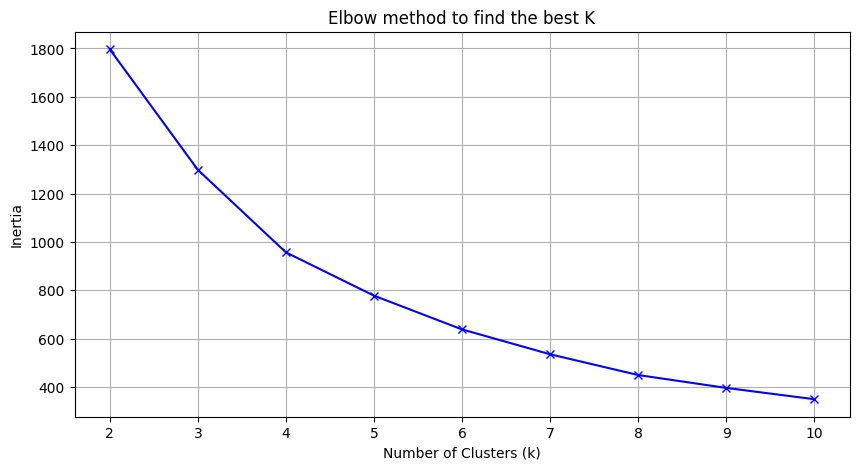

Silhouette scores:


{2: 0.4766256837305637,
 3: 0.3322185620054336,
 4: 0.40191892541792695,
 5: 0.47127705399623565,
 6: 0.45204740321966036,
 7: 0.4620760450667053,
 8: 0.44695612870700835,
 9: 0.46076497271348893,
 10: 0.4496019015853945}

In [ ]:
# Find the best k for K-means

inertia = []
scores = {}

K = range(2,11)

for k in K:
    kmodel = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmodel.fit(X_processed)
    inertia.append(kmodel.inertia_)
    score = silhouette_score(X_processed, kmodel.labels_)
    scores[k] = score

plt.figure(figsize=(10, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method to find the best K")
plt.grid(True)
plt.show()

print("Silhouette scores:")
display(scores)

**Notes**
- According to Silhouette scores, *k=3* and *k=4* have good scores.
- *K=5* looks a bit overlapped when we plot the clusters.
- However, it's important to check the distribution of each cluster before jumping into modeling.
- Also, we test different *K's* (from 5 to 9) to see which one gives better sMAPE scores.

In [14]:
NUM_K = 9

kmeans = KMeans(n_clusters=NUM_K, random_state=42, n_init=10)
store_features["Cluster"] = kmeans.fit_predict(X_processed)

store_features.head()

,Store,AvgSales,AvgCustomers,AvgCompetitionDistance,StoreType,Cluster
0,1,3945.704883,467.646497,1270.0,c,6
1,2,4122.991507,486.045648,570.0,a,1
2,3,5741.253715,620.286624,14130.0,a,4
3,4,8021.769639,1100.057325,620.0,c,0
4,5,3867.110403,444.360934,29910.0,a,1


**[Note]** Use the function *cluster_rossmann_stores* to get to the same results.

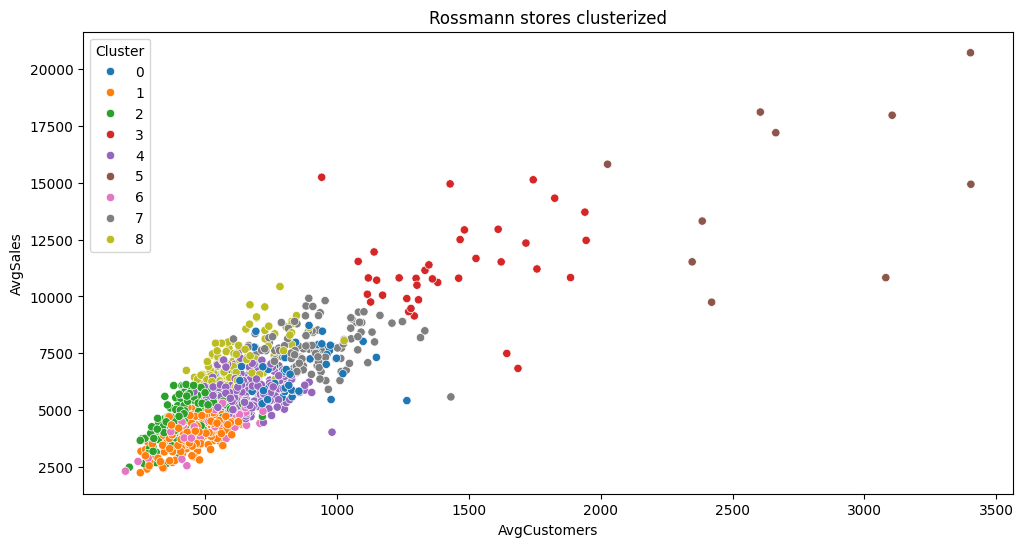

In [15]:
fig, ax = plt.subplots(figsize=(12,6))

cluster_colors = sns.color_palette("tab10")
sns.scatterplot(
    data=store_features,
    x="AvgCustomers",
    y="AvgSales",
    hue="Cluster",
    palette=cluster_colors
)
ax.set(title="Rossmann stores clusterized");


StoreType Distribution inside Clusters:


StoreType,a,b,c,d
Cluster,,,,
0,0,1,65,0
1,249,0,0,0
2,0,0,0,221
3,25,4,7,1
4,220,2,0,0
5,3,7,0,0
6,0,0,76,0
7,105,3,0,0
8,0,0,0,126


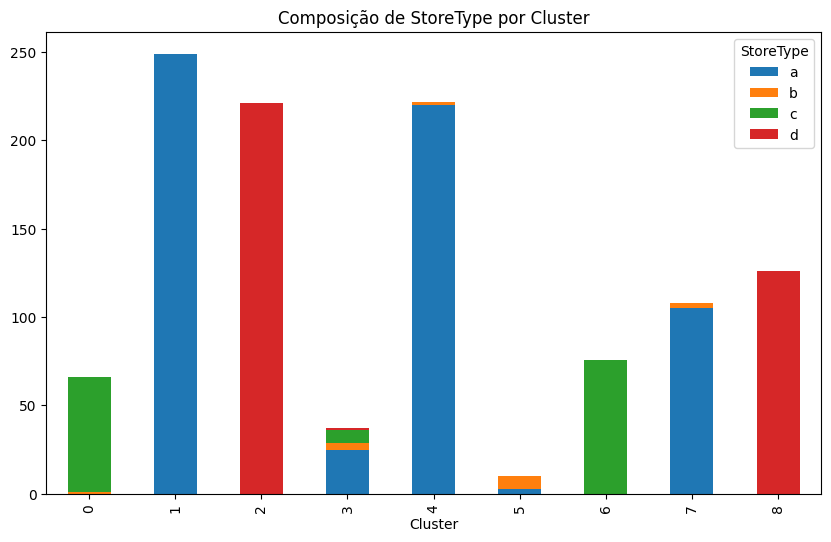

In [34]:
distribution_type = pd.crosstab(store_features['Cluster'], store_features['StoreType'])
print("\nStoreType Distribution inside Clusters:")
display(distribution_type)

distribution_type.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Composição de StoreType por Cluster')
plt.legend(title='StoreType')
plt.show()

In [35]:
cluster_sale_desc = store_features.groupby("Cluster")["AvgSales"].describe()
cluster_sale_desc.sort_values("mean").round(2)

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
1,249.0,4000.19,653.17,2244.50,3539.16,4012.90,4509.67,5477.61
6,76.0,4420.24,773.20,2313.47,4042.14,4441.60,4949.30,5805.72
2,221.0,4792.75,786.52,2485.84,4266.79,4877.63,5444.09,6126.55
4,222.0,5843.08,632.50,4027.61,5378.87,5812.55,6225.03,7588.34
0,66.0,6661.60,915.05,5276.15,5891.38,6606.41,7298.74,8857.61
8,126.0,7054.71,958.69,5727.35,6334.87,6774.94,7551.96,10433.38
7,108.0,7820.55,868.02,5579.38,7259.64,7710.06,8428.53,9917.41
3,37.0,11200.74,1919.07,6833.67,10053.74,10814.83,12346.30,15242.11
5,10.0,15014.83,3600.64,9744.60,11968.51,15373.69,17777.22,20718.52


#### Build models

In [ ]:
train_size = 0.8
cluster_features = ["ds", "y", "Open", "Promo", "DayOfWeek"]
rn = random.getrandbits(16)

forecasts_test = pd.DataFrame()
models_results = {}

for cluster_id in range(NUM_K):
    run_name = f"[{rn}] Cluster_{cluster_id}"
    print(f"Running cluster {cluster_id}")

    with mlflow.start_run(run_name=run_name):

        agg_x, cluster_ptrain = prepare_cluster_data_for_training(
            store_features=store_features,
            ptrain=ptrain,
            cluster_id=cluster_id,
            cluster_features=cluster_features
        )

        agg_x_train, agg_X_val, cap_by_day = split_cluster_data(
            train_size=train_size,
            agg_x=agg_x,
            margin=1.5
        )

        model = Prophet(
            seasonality_mode="multiplicative",
            growth="logistic"
        )
        model.add_country_holidays("DE")
        model.add_regressor("Open", mode="multiplicative")
        model.add_regressor("Promo", mode="multiplicative")
        model.fit(agg_x_train)

        future = model.make_future_dataframe(periods=agg_X_val.shape[0])
        future["Open"] = agg_x["Open"]
        future["Promo"] = agg_x["Promo"]
        future["DayOfWeek"] = agg_x["DayOfWeek"]
        future["cap"] = future["DayOfWeek"].map(cap_by_day)
        future["floor"] = 0

        forecast = model.predict(future)

        df_cv = cross_validation(
            model,
            initial="540 days",
            period="90 days",
            horizon="30 days",
            parallel="processes"
        )
        df_p = performance_metrics(df_cv)

        store_forecasts, scores_smapes = evaluate_model_performance_on_stores(
            model=model,
            cluster_ptrain=cluster_ptrain,
            cluster_features=cluster_features
        )
        stores_avg_smape = np.mean(scores_smapes)

        store_forecasts["Cluster"] = cluster_id
        forecasts_test = pd.concat([
            forecasts_test, store_forecasts],
            ignore_index=True
        )

        models_results[cluster_id] = {
            "model": model,
            "forecast": forecast
        }

        num_stores = store_features[store_features["Cluster"] == cluster_id].shape[0]
        cluster_smape = df_p["smape"].mean()

        print(f"\nCluster {cluster_id} - CV sMAPE = {cluster_smape} | " +
                f"Stores avg. sMAPE = {stores_avg_smape}")

        mlflow.log_metric("avg_cluster_smape", round(cluster_smape,3))
        mlflow.log_metric("avg_store_smape", round(stores_avg_smape,3))
        mlflow.log_metric("num_clusters", NUM_K)
        mlflow.log_param("cluster_size", num_stores)


In [ ]:
check_cluster_id = 0
check_forecast = models_results[check_cluster_id]["forecast"]

fig = model.plot(check_forecast)
fig2 = model.plot_components(check_forecast)

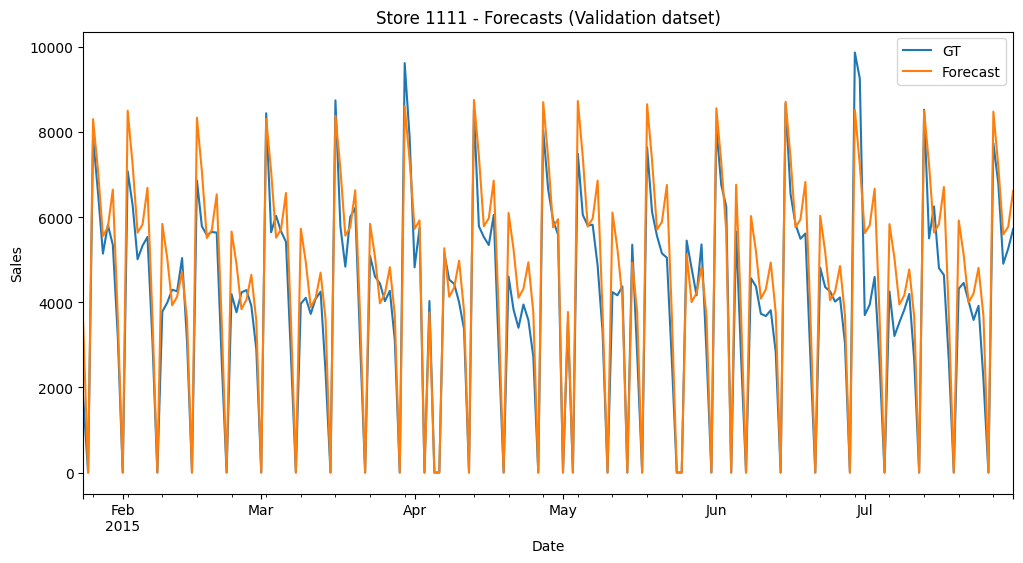

In [ ]:
check_sid = 1111
check_res = forecasts_test[forecasts_test["Store"] == check_sid]

fig, ax = plt.subplots(figsize=(12,6))
check_res.plot.line(x="ds", y="y", label="GT", ax=ax)
check_res.plot.line(x="ds", y="yhat", label="Forecast", ax=ax)

ax.set(title=f"Store {check_sid} - Forecasts (Validation datset)",
        xlabel="Date", ylabel="Sales");

### Modeling: XGBoost

Let's move to a gradient boost model called XGBoost. Since it does not understand
time natively as Prophet, we have to perform some adjustments so that it can
find time patterns in the dataset.

In [7]:
mlflow.set_tracking_uri("http://localhost:5001/")
mlflow.set_experiment("forecasting_rossmann_global")

<Experiment: artifact_location='s3://mlflow-artifacts/10', creation_time=1780384687148, experiment_id='10', last_update_time=1780384687148, lifecycle_stage='active', name='forecasting_rossmann_global', tags={}, trace_location=None, workspace='default'>

In [8]:
store_features = cluster_rossmann_stores(data=ptrain, store_data=pstore)

train_encoded = extended_preprocessing_rossmann_xgb(
    data=ptrain,
    profile_data=store_features,
    categorical_features=["StoreType", "Assortment", "Cluster"]
)

X_train, y_train, X_val, y_val = split_train_val_data(
    data=train_encoded,
    date_threshold="2015-01-01"
)

# Needed to correct predictions when predict Sales when Open=0
masks_by_length = {
    len(y_train): X_train["Open"].values,
    len(y_val): X_val["Open"].values,
}

rossmann_eval= RossmannEvaluation(
    masks_by_length=masks_by_length
)

print(f"Train size = {X_train.shape}")
print(f"Test size  = {X_val.shape}")

X_train.head(5)

Train size = (780829, 32)
Test size  = (236380, 32)


,Store,DayOfWeek,Open,Promo,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,year,month,...,Cluster_7,Cluster_8,IsHoliday,Sales_7,Sales_8,Sales_9,Sales_10,Sales_mean,Sales_sum,Sales_std
0,1,2,0,0,1270.0,9.0,2008.0,0,2013,1,...,False,False,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,3,1,0,1270.0,9.0,2008.0,0,2013,1,...,False,False,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,4,1,0,1270.0,9.0,2008.0,0,2013,1,...,False,False,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,5,1,0,1270.0,9.0,2008.0,0,2013,1,...,False,False,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,6,1,0,1270.0,9.0,2008.0,0,2013,1,...,False,False,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
mlflow.xgboost.autolog()
rn = random.getrandbits(16)

with mlflow.start_run(run_name=f"xgboost_global_{rn}"):
    model_xgb = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=1,
        objective="reg:tweedie",
        tweedie_variance_power=1.5,
        tree_method="hist",
        enable_categorical=True,
        eval_names=["train", "val"],
        eval_metric=rossmann_eval.smape_adjusted,
    )

    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train),(X_val, y_val)],
        verbose=50
    )

    preds = model_xgb.predict(X_val)
    preds = np.where(X_val['Open'] == 0, 0, preds)

    pred_smape = smape(y_true=y_val, y_pred=preds)
    print(f"sMAPE = {pred_smape:.3f}")

    mlflow.log_metric("sMAPE_test", round(pred_smape,3))

2026/09/15 09:36:08 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: tweedie-nloglik_at_1.2
2026/09/15 09:36:08 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: tweedie-nloglik_at_1.2


[0]	validation_0-tweedie-nloglik@1.2:6336.24748	validation_0-smape_adjusted:26.67759	validation_1-tweedie-nloglik@1.2:6456.55891	validation_1-smape_adjusted:26.05857


2026/09/15 09:36:08 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: tweedie-nloglik_at_1.2
2026/09/15 09:36:08 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: tweedie-nloglik_at_1.2
2026/09/15 09:36:08 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: tweedie-nloglik_at_1.2
2026/09/15 09:36:08 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: tweedie-nloglik_at_1.2
2026/09/15 09:36:09 INFO mlflow.xgboost._autolog: Identified one

[50]	validation_0-tweedie-nloglik@1.2:6069.41779	validation_0-smape_adjusted:11.01927	validation_1-tweedie-nloglik@1.2:6190.88844	validation_1-smape_adjusted:10.81385


2026/09/15 09:36:20 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: tweedie-nloglik_at_1.2
2026/09/15 09:36:20 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: tweedie-nloglik_at_1.2
2026/09/15 09:36:20 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: tweedie-nloglik_at_1.2
2026/09/15 09:36:20 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: tweedie-nloglik_at_1.2
2026/09/15 09:36:20 INFO mlflow.xgboost._autolog: Identified one

...

[450]	validation_0-tweedie-nloglik@1.2:6041.72102	validation_0-smape_adjusted:7.79429	validation_1-tweedie-nloglik@1.2:6165.00365	validation_1-smape_adjusted:8.75622


2026/09/15 09:38:07 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: tweedie-nloglik_at_1.2
2026/09/15 09:38:07 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: tweedie-nloglik_at_1.2
2026/09/15 09:38:07 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: tweedie-nloglik_at_1.2
2026/09/15 09:38:07 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: tweedie-nloglik_at_1.2
2026/09/15 09:38:07 INFO mlflow.xgboost._autolog: Identified one

[499]	validation_0-tweedie-nloglik@1.2:6041.48583	validation_0-smape_adjusted:7.66134	validation_1-tweedie-nloglik@1.2:6164.89660	validation_1-smape_adjusted:8.70356


2026/09/15 09:38:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/15 09:38:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


sMAPE = 8.704
🏃 View run xgboost_global_57418 at: http://localhost:5001/#/experiments/10/runs/7eeb38db8593439ea6af732d177600a4
🧪 View experiment at: http://localhost:5001/#/experiments/10


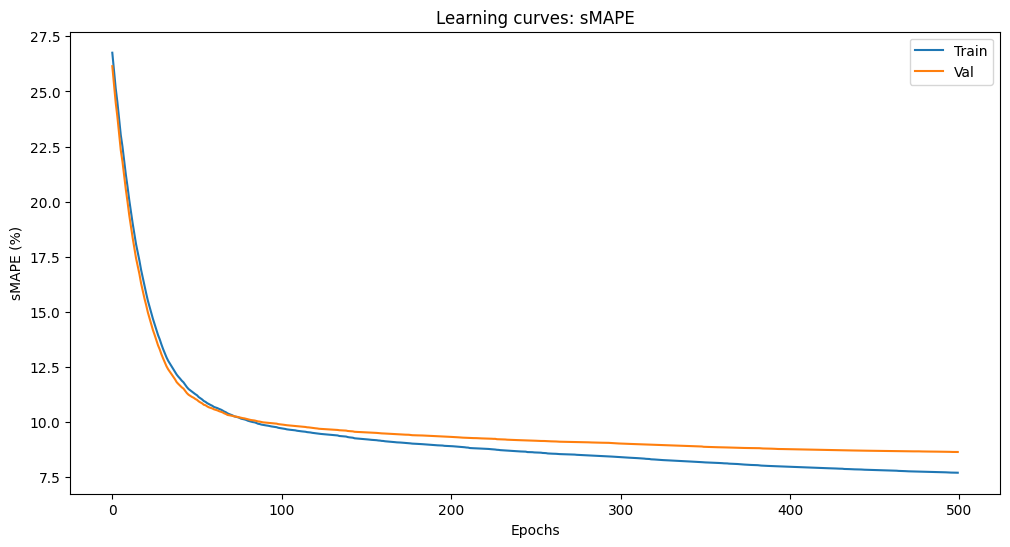

In [12]:
results = model_xgb.evals_result()

plt.figure(figsize=(12,6))

plt.plot(results['validation_0']['smape_adjusted'], label='Train')
plt.plot(results['validation_1']['smape_adjusted'], label='Val')
plt.title("Learning curves: sMAPE")
plt.xlabel("Epochs")
plt.ylabel("sMAPE (%)")
plt.legend()
plt.show()

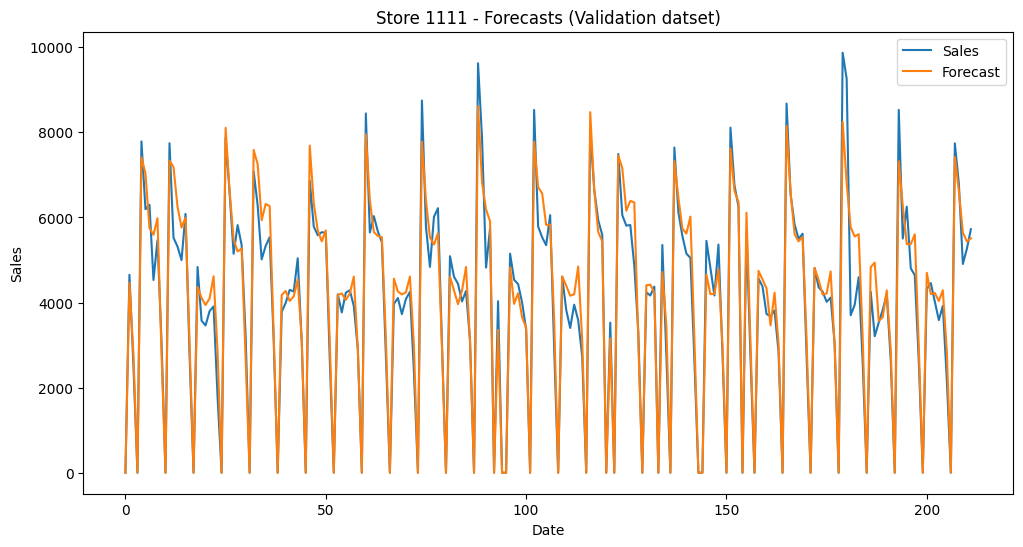

In [13]:
val_checks_df = X_val.copy()
val_checks_df["Sales"] = y_val
val_checks_df["Predictions"] = preds

check_sid = 1111
store_preds = val_checks_df[val_checks_df["Store"] == check_sid].copy()
store_preds.reset_index(drop=True, inplace=True)

fig, ax = plt.subplots(figsize=(12,6))
store_preds.plot.line(y="Sales", label="Sales", ax=ax)
store_preds.plot.line(y="Predictions", label="Forecast", ax=ax)

ax.set(title=f"Store {check_sid} - Forecasts (Validation datset)",
        xlabel="Date", ylabel="Sales");

____